In [217]:
import numpy as np
import matplotlib.pyplot as plt

# PART A

## A:1

In [56]:
N_list = [20, 2000]
my = 5
sigma = 2.7

for N in N_list:
    # (a)
    D = np.random.normal(my, sigma, size=N)
    
    # print(f"(a) N = {N}")
    # print(f"Dataset D: {D}")
    print(f"########################################\n#\tN = {N}\n########################################")



    # (b)
    m = np.mean(D)
    s = np.std(D)
    
    # print(f"(b)")
    # print(f"mean value of D: {m:.3f}")
    # print(f"std of D: {s:.3f}")


    # (c)
    B = 1000
    Db = np.zeros((B, N))
    Db_mean = np.zeros(B)
    Db_stds = np.zeros(B)

    for i in range(B):
        Db[i] = np.random.choice(D, size=N, replace=True)
        Db_mean[i] = np.mean(Db[i])
        Db_stds[i] = np.std(Db[i])
        
    # print(f"(c)")
    # print(f"Bootstrap mean: {np.mean(Db_mean[:]):.3f}")
    # print(f"Bootstrap std deviation: {np.mean(Db_stds[:]):.3f}")



    # (d)
    a_20 = np.percentile(Db_mean, 2.5)
    b_20 = np.percentile(Db_mean, 97.5)
    
    # print(f"(d)")
    print(f"\n95% bootstrap percentile interval for meanvalues\n[{a_20:.3f}, {b_20:.3f}]")
    
    
    
    # (f)
    a_20 = np.percentile(Db_stds, 2.5)
    b_20 = np.percentile(Db_stds, 97.5)
    
    # print(f"(f)")
    print(f"\n95% bootstrap percentile interval for std\n[{a_20:.3f}, {b_20:.3f}]\n")

print(f"True mean value: {my}")
print(f"True std value: {sigma}")

########################################
#	N = 20
########################################

95% bootstrap percentile interval for meanvalues
[4.176, 6.670]

95% bootstrap percentile interval for std
[2.095, 3.447]

########################################
#	N = 2000
########################################

95% bootstrap percentile interval for meanvalues
[4.908, 5.139]

95% bootstrap percentile interval for std
[2.562, 2.727]

True mean value: 5
True std value: 2.7


## A:2

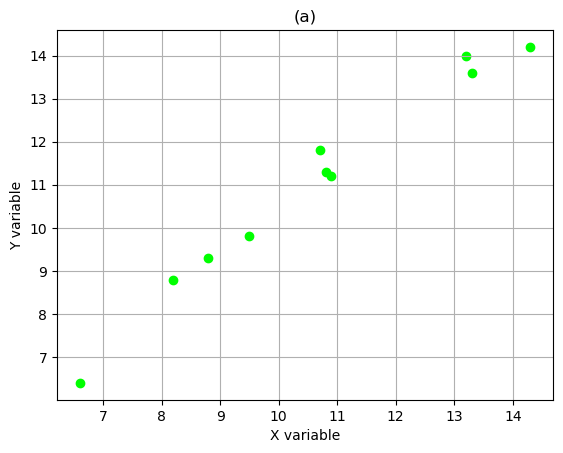

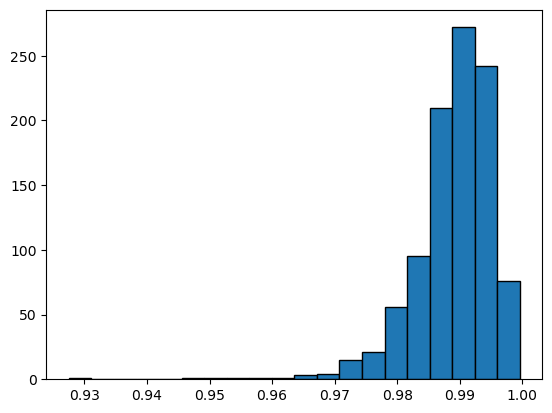

[0.989358   0.99929416 0.97630885 0.99453893 0.9891389  0.98931517
 0.99639449 0.9923372  0.9872192  0.99805107 0.98988597 0.98734138
 0.9955053  0.99888237 0.99274458 0.98856832 0.99138649 0.98907263
 0.98844053 0.98923887 0.98854175 0.99070713 0.98846973 0.98987264
 0.97997458 0.99205682 0.99037415 0.98337726 0.99028821 0.99327632
 0.99151632 0.98676413 0.99254095 0.99059194 0.9893574  0.99532671
 0.99368265 0.9972612  0.9877296  0.98295018 0.99613118 0.98352991
 0.98575943 0.99338514 0.98745818 0.97919875 0.99391881 0.97778221
 0.98876218 0.99010659 0.99328893 0.99154946 0.99717617 0.98500385
 0.98385332 0.99059142 0.98161441 0.99536436 0.99053979 0.99070713
 0.99398508 0.98774033 0.98872431 0.98513354 0.99427769 0.98076266
 0.9916667  0.98634736 0.98387786 0.99385729 0.98785306 0.9904655
 0.98829572 0.98364819 0.96141046 0.99646179 0.9896199  0.98848055
 0.99558076 0.98734625 0.98810336 0.98935658 0.99605443 0.98440862
 0.99505575 0.98841445 0.98638412 0.99180389 0.9275142  0.98417

In [ ]:
# I chose the Industrial Analytics formulation

X = np.asarray([13.2, 8.2, 10.9, 14.3, 10.7, 6.6, 9.5, 10.8, 8.8, 13.3])
Y = np.asarray([14.0, 8.8, 11.2, 14.2, 11.8, 6.4, 9.8, 11.3, 9.3, 13.6])

# (a)
plt.scatter(X, Y, color="lime")
plt.xlabel("X variable")
plt.ylabel("Y variable")
plt.title("(a)")
plt.grid()
plt.show()

# Yes, to me they seem to be correlated


# (b)
P = np.corrcoef(X, Y)

# The answer is 0.988226 which is far from zero and close to 1
# That indicates to me that it has a high correlation
# The close to 1 the value is, the more correlated are they


# (c)
B = 10
N = 1000
Dataset_b = np.zeros((N, B, 2)) # N datasets, with B datapoints, and 2 values for X and Y
P_b = np.zeros(N)

pairs = np.asarray(list(zip(X,Y)))

for i in range(N):
    random_pairs = np.random.choice(len(pairs), size=B, replace=True)
    Dataset_b[i] = pairs[random_pairs]
    temp_P_b = np.corrcoef(Dataset_b[i][:,0], Dataset_b[i][:,1])
    P_b[i] = temp_P_b[0][1]

plt.hist(P_b, bins=20, edgecolor="black")
plt.show()

a_1000 = np.percentile(P_b, 2.5)
b_1000 = np.percentile(P_b, 97.5)

print(f"95% bootstrap confidence of correlation: [{a_1000:.6f}, {b_1000:.6f}]")
print(f"True correlation value: {round(P[0][1], 6)}")

# This does not contain the origin.
# I still believe that they're correlated becuase it's still near zero.
# They're correlated to eachother

## A:3

95% bootstrap confidence interval for frac errors:
[0.133, 0.350]


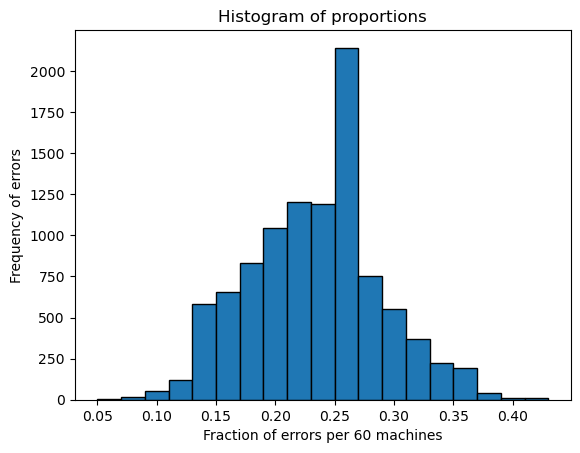

In [173]:
N = 10**4

urn = np.asarray([1]*14 + [0]*46)   # 1 = red ball, 0 = white ball
frac_errors = np.zeros(N)

for i in range(N):
    draw_urn = np.random.choice(urn, size=60, p=None, replace=True)
    frac_errors[i] = np.sum(draw_urn)/60

boundry = [n/50+0.05 for n in range(20)]
plt.hist(frac_errors, bins=boundry, edgecolor="black")
plt.xlabel("Fraction of errors per 60 machines")
plt.ylabel("Frequency of errors")
plt.title("Histogram of proportions")
# plt.show()

a_10000 = np.percentile(frac_errors, 2.5)
b_10000 = np.percentile(frac_errors, 97.5)
print(f"95% bootstrap confidence interval for frac errors:\n[{a_10000:.3f}, {b_10000:.3f}]")

## A:4

In [189]:
N = 20
urn = np.asarray([1]*4 + [0]*16)
frac_errors = np.zeros(N)

for i in range(N):
    draw_urn = np.random.choice(urn, size=N, p=None, replace=True)
    frac_errors[i] = np.sum(draw_urn)/N
    
a_20 = np.percentile(frac_errors, 2.5)
b_20 = np.percentile(frac_errors, 97.5)
print(f"95% bootstrap confidence interval for frac errors:\n[{a_20*100:.1f}%, {b_20*100:.1f}%]")

95% bootstrap confidence interval for frac errors:
[5.0%, 35.2%]


## A:5

### (a)

In [30]:
N = 10000
urn = np.asarray([1]*89 + [0]*(96-89))
frac_errors = np.zeros(N)

for n in range(N):
    draw_urn = np.random.choice(urn, size=96, p=None, replace=True)
    frac_errors[n] = np.sum(draw_urn)/96
    
a_10000 = np.percentile(frac_errors, 2.5)
b_10000 = np.percentile(frac_errors, 97.5)
print(f"95% bootstrap confidence interval for frac errors:\n[{round(a_10000*100)}%, {round(b_10000*100)}%]")

95% bootstrap confidence interval for frac errors:
[88%, 98%]


### (b)

In [29]:
N = 10000
well = 384
urn = np.asarray([1]*357 + [0]*(well-357))
frac_errors = np.zeros(N)

for n in range(N):
    draw_urn = np.random.choice(urn, size=well, p=None, replace=True)
    frac_errors[n] = np.sum(draw_urn)/well
    
a_10000 = np.percentile(frac_errors, 2.5)
b_10000 = np.percentile(frac_errors, 97.5)
print(f"95% bootstrap confidence interval for frac errors:\n[{round(a_10000*100)}%, {round(b_10000*100)}%]")

95% bootstrap confidence interval for frac errors:
[90%, 95%]


### (c)

In [28]:
N = 10000
well = 1536
urn = np.asarray([1]*1428 + [0]*(well-1428))
frac_errors = np.zeros(N)

for n in range(N):
    draw_urn = np.random.choice(urn, size=well, p=None, replace=True)
    frac_errors[n] = np.sum(draw_urn)/well
    
a_10000 = np.percentile(frac_errors, 2.5)
b_10000 = np.percentile(frac_errors, 97.5)
print(f"95% bootstrap confidence interval for frac errors:\n[{round(a_10000*100)}%, {round(b_10000*100)}%]")

95% bootstrap confidence interval for frac errors:
[92%, 94%]


# Part B

## B:1

In [209]:
N = 20
B = 10**4
urn = np.asarray([1]*1 + [0]*1)
errors = np.zeros(B)

for n in range(B):
    draw_urn = np.random.choice(urn, size=N, p=None, replace=True)
    errors[n] = np.sum(draw_urn)

print(errors)
print(len(errors[errors <= 7])/B)
# The value is at 0.131 which tells me that it is NOT significant.
# The classifier is guessing and not doing a good job.

[ 8. 11.  9. ... 10. 12. 12.]
0.1302
0.1302


## B:2

### (a)

In [218]:
# I chose the industrial analytics formulation
B = 10**5
N = 1200
urn = np.asarray([1]*900 + [0]*(N-900))
success = np.zeros(B)

for b in range(B):
    draw_urn = np.random.choice(urn, size=N, replace=True)
    success[b] = np.sum(draw_urn)

# print(success)
print(len(success[success <= (900/N)])/B)
# The p-value is high meaning that it dosen't really mean anything.
# The 75% that was tested before is not impossible
# The manufacturer could still be right

0.0


### (b)

In [112]:
# I chose the industrial analytics formulation
B = 10**5
N = 12
urn = np.asarray([1]*9 + [0]*(N-9))
success = np.zeros(B)

for b in range(B):
    draw_urn = np.random.choice(urn, size=N, replace=True)
    success[b] = np.sum(draw_urn)/N

print(len(success[success <= (9/N)])/B)
# Same thing?

0.60985


## B:3

In [228]:
B = 10**4
N = 96
urn = np.asarray([1]*93 + [0]*7)
success = np.zeros(B)

for b in range(B):
    draw_urn = np.random.choice(urn, size=N, replace=True)
    success[b] = np.sum(draw_urn)
    
c = np.percentile(success, 5)
print(f"5% percentile resulting distribution:\n{round(c, 2)}")
# Over 84 so the null hypothesis is rejected
print(len(success[success <= (93/N)])/B)

5% percentile resulting distribution:
85.0
0.0


## B:4

In [ ]:
B = 10**4
women = [60,62,73,81,27,72,61,59,42,39,71,74]
men = [74,79,80,89,71,72,92,67,91,83,43]

mean_women = np.mean(women)
mean_men = np.mean(men)

d_obs = mean_women - mean_men
print(f"Observed difference: {d_obs:.2f}")

d_sim = np.zeros(B)
urn = np.asarray(women + men)
for b in range(B):
    draw_urn_12 = np.random.choice(urn, size=12, replace=True)
    draw_urn_11 = np.random.choice(urn, size=11, replace=True)

    mean_12 = np.mean(draw_urn_12)
    mean_11 = np.mean(draw_urn_11)

    d_sim[b] = mean_12 - mean_11
    
p_value = np.mean(np.abs(d_sim) >= np.abs(d_obs))
print(f"p-value: {p_value:.4f}")
# There is a difference between men and women.
# The observed p-value is 0.0179 which is less than 0.05.
# That indicates that there is a difference between men and women.

Observed difference: -16.37
p-value: 0.0179


## B:5

In [159]:
levels_in_factory_A = [13.2, 8.2, 10.9, 14.3, 10.7, 6.6, 9.5, 10.8, 8.8, 13.3]
levels_in_factory_B = [14.0, 8.8, 11.2, 14.2, 11.8, 6.4, 9.8, 11.3, 9.3, 13.6]

### (a)

In [160]:
mean_A = np.mean(levels_in_factory_A)
mean_B = np.mean(levels_in_factory_B)
mean_diff = mean_A - mean_B
print(f"Mean difference: {mean_diff:.2f}")
# Spontaneous answer is that there is a small difference between the two factories

Mean difference: -0.41


### (b)

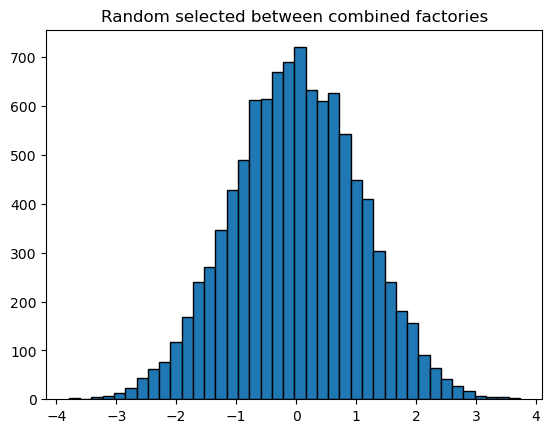

p-value: 0.71


In [166]:
B = 10**4
values_A_and_B = np.asarray(levels_in_factory_A + levels_in_factory_B)
mean_diffs = np.zeros(B)

for b in range(B):
    draw_values_A = np.random.choice(values_A_and_B, size=10, replace=True)
    draw_values_B = np.random.choice(values_A_and_B, size=10, replace=True)
    
    mean_sim_A = np.mean(draw_values_A)
    mean_sim_B = np.mean(draw_values_B)
    
    mean_diffs[b] = mean_sim_A - mean_sim_B

plt.hist(mean_diffs, bins=40, edgecolor="black")
plt.title("Random selected between combined factories")
plt.show()
p_value = np.mean(np.abs(mean_diffs) >= np.abs(mean_diff))
print(f"p-value: {p_value:.2f}")
# p-value dosen't indicate that there is a difference between the two factories.
# The p-value is 0.7 which is greater than 0.05.
# That tells me that there isn't a big enough difference between the two to make that deduction.

### (c)

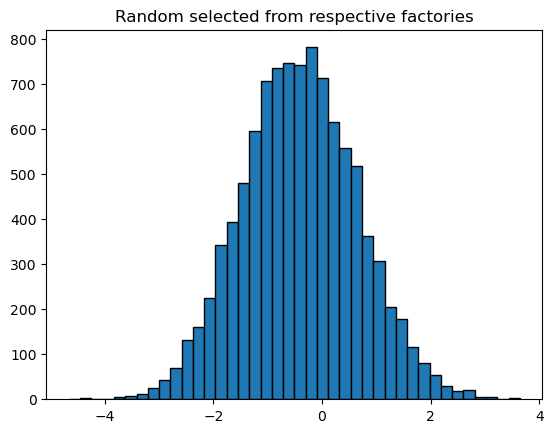

95% bootstrap confidence interval for mean difference:
[-2.45, 1.68]


In [167]:
B = 10**4
diff = np.zeros(B)

for b in range(B):
    A_sim = np.random.choice(levels_in_factory_A, size=10, replace=True)
    B_sim = np.random.choice(levels_in_factory_B, size=10, replace=True)

    diff[b] = np.mean(A_sim) - np.mean(B_sim)

plt.hist(diff, bins=40, edgecolor="black")
plt.title("Random selected from respective factories")
plt.show()
a_diff = np.percentile(diff, 2.5)
b_diff = np.percentile(diff, 97.5)
print(f"95% bootstrap confidence interval for mean difference:\n[{a_diff:.2f}, {b_diff:.2f}]")
# 95% spans between -2.41 and 1.70 which includes zero.
# That tells me that there might not be a difference between the two.

## B:6

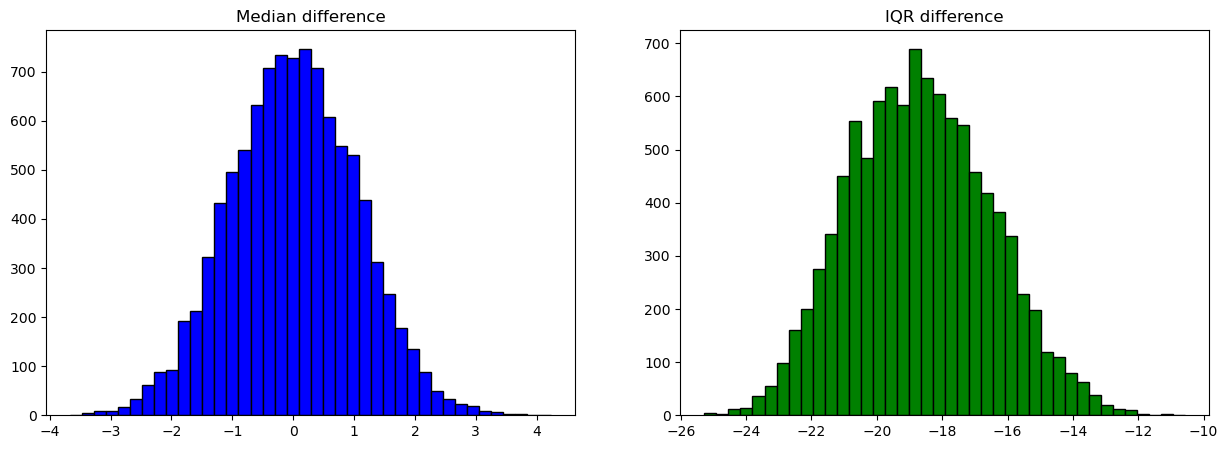

p-value for median: 0.64
p-value for IQR: 1.00


In [226]:
values_of_group_A = [13.2, 8.2, 10.9, 14.3, 10.7, 6.6, 9.5, 10.8, 8.8, 13.3]
values_of_group_B = [14.0, 8.8, 11.2, 14.2, 11.8, 6.4, 9.8, 11.3, 9.3, 13.6]

median_A = np.median(values_of_group_A)
median_B = np.median(values_of_group_B)
median_diff = median_A - median_B

IQR_A = np.percentile(values_of_group_A, 75) - np.percentile(values_of_group_A, 25)
IQR_B = np.percentile(values_of_group_B, 75) - np.percentile(values_of_group_B, 25)

d_IQR = IQR_A - IQR_B

B = 10**4
d_sim = np.zeros(B)
d_IQR_sim = np.zeros(B)
values_A_and_B = np.asarray(values_of_group_A + values_of_group_B)

for b in range(B):
    draw_values_A = np.random.choice(values_A_and_B, size=10, replace=True)
    draw_values_B = np.random.choice(values_A_and_B, size=10, replace=True)
    d_sim[b] = np.mean(draw_values_A) - np.mean(draw_values_B)
    d_IQR_sim[b] = (np.percentile(draw_values_A, 75) - np.percentile(draw_values_A, 25)) - (np.percentile(draw_values_B, 75) + np.percentile(draw_values_B, 25))

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.hist(d_sim, bins=40, color="blue", edgecolor="black")
plt.title("Median difference")

plt.subplot(1,2,2)
plt.hist(d_IQR_sim, bins=40, color="green", edgecolor="black")
plt.title("IQR difference")

plt.show()

p_value_median = np.mean(np.abs(d_sim) >= np.abs(median_diff))
p_value_IQR = np.mean(np.abs(d_IQR_sim) >= np.abs(d_IQR))
print(f"p-value for median: {p_value_median:.2f}")
print(f"p-value for IQR: {p_value_IQR:.2f}")

## B:7

Correlation: -0.0860613824020251


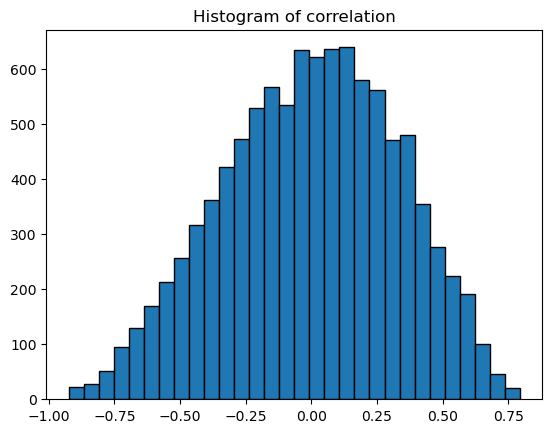

p-value: 0.81


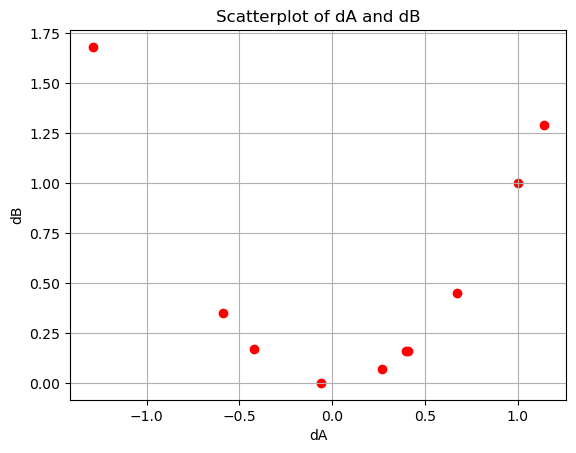

In [225]:
dA = [0.67,-1.29,-0.42,0.27,-0.59,-0.06, 0.41,0.40,1.00, 1.14]
dB = [0.45,1.68,0.17,0.07,0.35,0.00,0.16,0.16,1.00,1.29]

r = np.corrcoef(dA, dB)[0][1]
print(f"Correlation: {r}")

B = 10**4
r_sim = np.zeros(B)

for b in range(B):
    np.random.shuffle(dA)
    r_sim[b] = np.corrcoef(dA, dB)[0][1]

plt.hist(r_sim, bins=30, edgecolor="black")
plt.title("Histogram of correlation")
plt.show()

p_value = np.mean(np.abs(r_sim) >= np.abs(r))
print(f"p-value: {p_value:.2f}")
# I can't reject the null hypothesis

dA = [0.67,-1.29,-0.42,0.27,-0.59,-0.06, 0.41,0.40,1.00, 1.14]
plt.scatter(dA, dB, color="red")
plt.xlabel("dA")
plt.ylabel("dB")
plt.title("Scatterplot of dA and dB")
plt.grid()
plt.show()
# Pearson's correlation is a linnear relationship and not a quadratic one.
# That's why it's not ale to pick up that the relationship is a quadratic one.